# Trust Study Response Generation

This notebook prepares a flow-aware synthetic run for `survey_trust_new.qsf`, previews the Qualtrics flow, builds seeded random adult U.S. participant samples from the packaged GSS persona pool, and sets up both a tiny pilot and the full requested allocation derived from the active survey conditions.

Assumptions used here:
- The survey's top-level even-presentation randomizer is detected from `TOP_LEVEL_RANDOMIZER_ID`.
- Control branches are detected from condition labels that start with `control`.
- The plan's `1,000` control participants are split across active control variants as evenly as possible.
- The tiny pilot derives its size from the active survey setup and assigns `1` participant to each active condition, including each control.
- The runtime requires explicit intervention overrides for Qualtrics intervention nodes, so this notebook auto-builds text-only overrides from the survey content itself.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import pandas as pd
from openai import OpenAI

from simulate import load_gss_personas, load_prompts, visualize_survey_flow
from simulate.lab import Lab
from simulate.survey import Survey


In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / 'simulate').exists():
    for parent in ROOT.parents:
        if (parent / 'simulate').exists():
            ROOT = parent
            break

SURVEY_PATH = ROOT / "studies" / "trust" / "survey_trust_new.qsf"
PROMPTS_PATH = ROOT / "simulate" / "personas" / "prompts.json"
RESULTS_DIR = ROOT / "studies" / "trust" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
USER_MODEL = "openai/gpt-4o-mini" #"openai/gpt-5.4-mini"
USER_TEMPERATURE = 1.2
USER_MAX_TOKENS = 512
PARTICIPANT_PROMPT_NAME = "gss_prompt"

FULL_TREATMENT_COUNT = 500
FULL_CONTROL_TOTAL = 1_000
FULL_PARTICIPANT_COUNT = None
PILOT_TREATMENT_COUNT = 1
TOP_LEVEL_RANDOMIZER_ID = "FL_18"
survey = Survey(str(SURVEY_PATH))


In [3]:
BLOCKS_TO_SKIP = [
    "Consent Form",
    "Filter",
    "Attention Check",
]

survey.set_excluded_blocks(BLOCKS_TO_SKIP)
print("Excluded blocks:", BLOCKS_TO_SKIP)


Excluded blocks: ['Consent Form', 'Filter', 'Attention Check']


In [4]:
def make_client() -> OpenAI:
    if os.environ.get("OPENROUTER_API_KEY"):
        return OpenAI(
            base_url=os.environ.get("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1"),
            api_key=os.environ["OPENROUTER_API_KEY"],
        )
    if os.environ.get("OPENAI_API_KEY"):
        return OpenAI(api_key=os.environ["OPENAI_API_KEY"])
    raise RuntimeError("Set OPENAI_API_KEY or OPENROUTER_API_KEY before running live generation cells.")


def load_participant_prompt(prompt_name: str = PARTICIPANT_PROMPT_NAME) -> dict[str, str]:
    prompt_library = load_prompts(str(PROMPTS_PATH))
    if prompt_name not in prompt_library:
        available = ", ".join(sorted(prompt_library))
        raise KeyError(f"Unknown participant prompt {prompt_name!r}. Available prompts: {available}")
    return {prompt_name: prompt_library[prompt_name]}


def load_adult_gss_personas() -> pd.DataFrame:
    personas = load_gss_personas().copy()
    personas["age"] = pd.to_numeric(personas["age"], errors="coerce")
    personas = personas[personas["age"] >= 18].copy()
    personas["id"] = personas["id"].astype(str)
    return personas


def sample_gss_personas(df: pd.DataFrame, n: int, *, seed: int, sample_name: str) -> pd.DataFrame:
    if n <= 0:
        raise ValueError("n must be positive")
    if df.empty:
        raise ValueError("Cannot sample from an empty GSS persona pool")

    replace = n > len(df)
    sampled = df.sample(n=n, replace=replace, random_state=seed).reset_index(drop=True).copy()
    sampled["source_persona_id"] = sampled["id"].astype(str)
    sampled["sample_name"] = sample_name
    sampled["sample_index"] = range(1, n + 1)
    sampled["id"] = [f"{sample_name}_{index:05d}" for index in sampled["sample_index"]]
    return sampled


def find_randomizer_node(flow_id: str = TOP_LEVEL_RANDOMIZER_ID) -> dict:
    stack = list(survey.flow_data.get("flow", {}).get("Flow", []))
    while stack:
        node = stack.pop(0)
        if node.get("FlowID") == flow_id:
            return node
        stack[:0] = list(node.get("Flow", []))
    raise KeyError(f"Could not find randomizer {flow_id}")


def extract_condition_options(flow_id: str = TOP_LEVEL_RANDOMIZER_ID) -> list[dict[str, str]]:
    node = find_randomizer_node(flow_id)
    options = []
    active_children = survey._get_active_randomizer_children(node) if hasattr(survey, "_get_active_randomizer_children") else node.get("Flow", [])
    for child in active_children:
        embedded = child.get("EmbeddedData", [])
        condition_label = str(embedded[0].get("Value")) if embedded else str(child.get("Description") or child.get("FlowID"))
        option_key = child.get("Description") or child.get("ID") or child.get("FlowID")
        options.append(
            {
                "flow_option": str(option_key),
                "flow_id": str(child.get("FlowID") or option_key),
                "condition_label": condition_label,
            }
        )
    return options


def split_condition_options(condition_options: list[dict[str, str]]) -> tuple[list[dict[str, str]], list[dict[str, str]]]:
    controls = [option for option in condition_options if option["condition_label"].strip().lower().startswith("control")]
    treatments = [option for option in condition_options if option not in controls]
    return treatments, controls


def build_full_condition_counts(condition_options: list[dict[str, str]]) -> dict[str, int]:
    treatment_options, control_options = split_condition_options(condition_options)
    counts = {option["flow_option"]: FULL_TREATMENT_COUNT for option in treatment_options}
    if control_options:
        base, remainder = divmod(FULL_CONTROL_TOTAL, len(control_options))
        for index, option in enumerate(control_options):
            counts[option["flow_option"]] = base + (1 if index < remainder else 0)

    ordered_counts = {option["flow_option"]: counts[option["flow_option"]] for option in condition_options}
    if FULL_PARTICIPANT_COUNT is not None and sum(ordered_counts.values()) != FULL_PARTICIPANT_COUNT:
        raise ValueError(f"Full condition counts do not sum to {FULL_PARTICIPANT_COUNT} participants.")
    return ordered_counts


def build_pilot_condition_counts(condition_options: list[dict[str, str]]) -> dict[str, int]:
    counts = {option["flow_option"]: PILOT_TREATMENT_COUNT for option in condition_options}
    expected_total = len(condition_options) * PILOT_TREATMENT_COUNT
    if sum(counts.values()) != expected_total:
        raise ValueError(f"Pilot condition counts do not sum to {expected_total} participants.")
    return counts


def build_text_only_intervention_overrides(survey: Survey) -> dict[str, dict]:
    conditions = {}
    for meta in survey.flow_data.get("questions", {}).values():
        if meta.get("runtime_type") != "intervention":
            continue
        raw_unsafe = str(meta.get("raw_payload", {}).get("QuestionText_Unsafe", ""))
        if "<iframe" in raw_unsafe.lower():
            text = "[Embedded interactive treatment content omitted in text-only simulation.]"
        else:
            text = meta.get("text") or ""
        conditions[meta["data_export_tag"]] = {
            "text": text,
            "completion_code": "SIMULATED_INTERVENTION",
        }
    return {"defaults": {}, "conditions": conditions}


def run_batch(
    personas_df: pd.DataFrame,
    participant_ids: list[str],
    participant_prompt: dict[str, str],
    condition_counts: dict[str, int],
    intervention_overrides: dict,
):
    client = make_client()
    lab = Lab(
        client=client,
        df=personas_df.copy(),
        user_model=USER_MODEL,
        user_temperature=USER_TEMPERATURE,
        user_max_tokens=USER_MAX_TOKENS,
        seed=SEED,
    )
    plan = lab.describe_even_presentation_plan(
        sampled_users=participant_ids,
        user_system_texts=participant_prompt,
        survey=survey,
        even_presentation_counts={TOP_LEVEL_RANDOMIZER_ID: condition_counts},
    )
    raw_results = lab.run_survey(
        sampled_users=participant_ids,
        user_system_texts=participant_prompt,
        survey=survey,
        context_mode="none",
        intervention_overrides=intervention_overrides,
        even_presentation_counts={TOP_LEVEL_RANDOMIZER_ID: condition_counts},
    )
    formatted_results = lab.format_results(raw_results, survey)
    return lab, plan, raw_results, formatted_results


In [5]:
flow_blocks = pd.DataFrame(survey.describe_flow_blocks())
flow_randomizers = pd.DataFrame(survey.describe_flow_randomizers())
condition_options = extract_condition_options()
treatment_options, control_options = split_condition_options(condition_options)
full_condition_counts = build_full_condition_counts(condition_options)
pilot_condition_counts = build_pilot_condition_counts(condition_options)
text_only_intervention_overrides = build_text_only_intervention_overrides(survey)
participant_prompt = load_participant_prompt()

print("Survey warnings:", survey.warnings)
print("Total scales:", len(survey.scales))
print("Top-level condition count:", len(condition_options))
print("Treatment labels:", len(treatment_options))
print("Control labels:", [option["condition_label"] for option in control_options])
print("Intervention override keys:", len(text_only_intervention_overrides["conditions"]))


Survey warnings: []
Total scales: 89
Top-level condition count: 18
Treatment labels: 16
Control labels: ['Control', 'Control (second for twice as many)']
Intervention override keys: 0


In [6]:
flow_blocks

,block_id,description,question_count,question_ids,runtime_summary,excluded
0,BL_b4nxolDPBjQHMTY,Consent Form,2,"[QID1721185776, QID1721185777]","{'display': 1, 'passive': 1}",True
1,BL_0My4IaAYJZG5ipE,Filter,3,"[QID1721185780, QID1721185781, QID1721185782]","{'scale': 2, 'passive': 1}",True
2,BL_79w7FHdEWKx3arI,demographics,12,"[QID1721185783, QID1721185784, QID1721185785, ...","{'scale': 11, 'passive': 1}",False
3,BL_3q0OXxthSBXE6vI,Partisan identity,2,"[QID1721185795, QID1721185797]","{'scale': 1, 'passive': 1}",False
4,BL_28YgqMfQofBlfzo,Partisan importance,2,"[QID281, QID282]","{'scale': 1, 'passive': 1}",False
5,BL_1AL5bUgWqR2BmPc,Religion,2,"[QID1721185824, QID1721185827]","{'scale': 1, 'passive': 1}",False
6,BL_ePtUBLL1afIpSrs,born again,2,"[QID287, QID289]","{'scale': 1, 'passive': 1}",False
7,BL_bJmKSNVK3bth13M,Religiosity,2,"[QID285, QID286]","{'scale': 1, 'passive': 1}",False
8,BL_6nV95kxe6IidavQ,epistemic autonomy,8,"[QID1721186008, QID1721186009, QID1721186010, ...","{'display': 1, 'scale': 6, 'passive': 1}",False
9,BL_9HnEBwYiBv53FXg,Attention Check,2,"[QID1721185922, QID1721185923]","{'scale': 1, 'passive': 1}",True


In [7]:
flow_randomizers[["flow_id", "path", "subset", "option_count", "even_presentation", "options"]]


,flow_id,path,subset,option_count,even_presentation,options
0,FL_16,Survey Flow > FL_16,3,3,False,"[belief pre, trust single pre, alienation]"
1,FL_18,Survey Flow > FL_18,1,18,True,"[Control, Control (second for twice as many), ..."
2,FL_229,Survey Flow > FL_18 > Control > FL_229,1,3,True,"[FL_230, FL_231, FL_232]"
3,FL_225,Survey Flow > FL_18 > Control (second for twic...,1,3,True,"[FL_226, FL_227, FL_228]"
4,FL_137,Survey Flow > New Branch > FL_137,3,3,False,"[jealous jaguar - human, jealous jaguar - CO2,..."
5,FL_55,Survey Flow > Secondary outcomes > FL_55,7,7,False,"[trust single post, donation, distrust single ..."
6,FL_49,Survey Flow > Tertiary outcomes > FL_49,5,5,False,"[belief post, climate change concern, individu..."


In [8]:
pd.DataFrame(
    {
        "flow_option": [option["flow_option"] for option in condition_options],
        "condition_label": [option["condition_label"] for option in condition_options],
        "pilot_n": [pilot_condition_counts[option["flow_option"]] for option in condition_options],
        "full_n": [full_condition_counts[option["flow_option"]] for option in condition_options],
        "is_control": [option["condition_label"].strip().lower().startswith("control") for option in condition_options],
    }
)


,flow_option,condition_label,pilot_n,full_n,is_control
0,Control,Control,1,500,True
1,Control (second for twice as many),Control (second for twice as many),1,500,True
2,FL_208,practical planarian,1,500,False
3,FL_209,jealous jaguar,1,500,False
4,FL_210,perfect prawn,1,500,False
5,FL_212,difficult dog,1,500,False
6,FL_213,flimsy fish,1,500,False
7,FL_214,phony parrotfish,1,500,False
8,FL_215,worse wildfowl,1,500,False
9,FL_216,limping llama; friendly frog,1,500,False


## Survey Flow Visualization

This cell renders the parsed Qualtrics flow so we can sanity-check the major blocks, randomizers, and post-treatment sections before running any model-backed simulation.


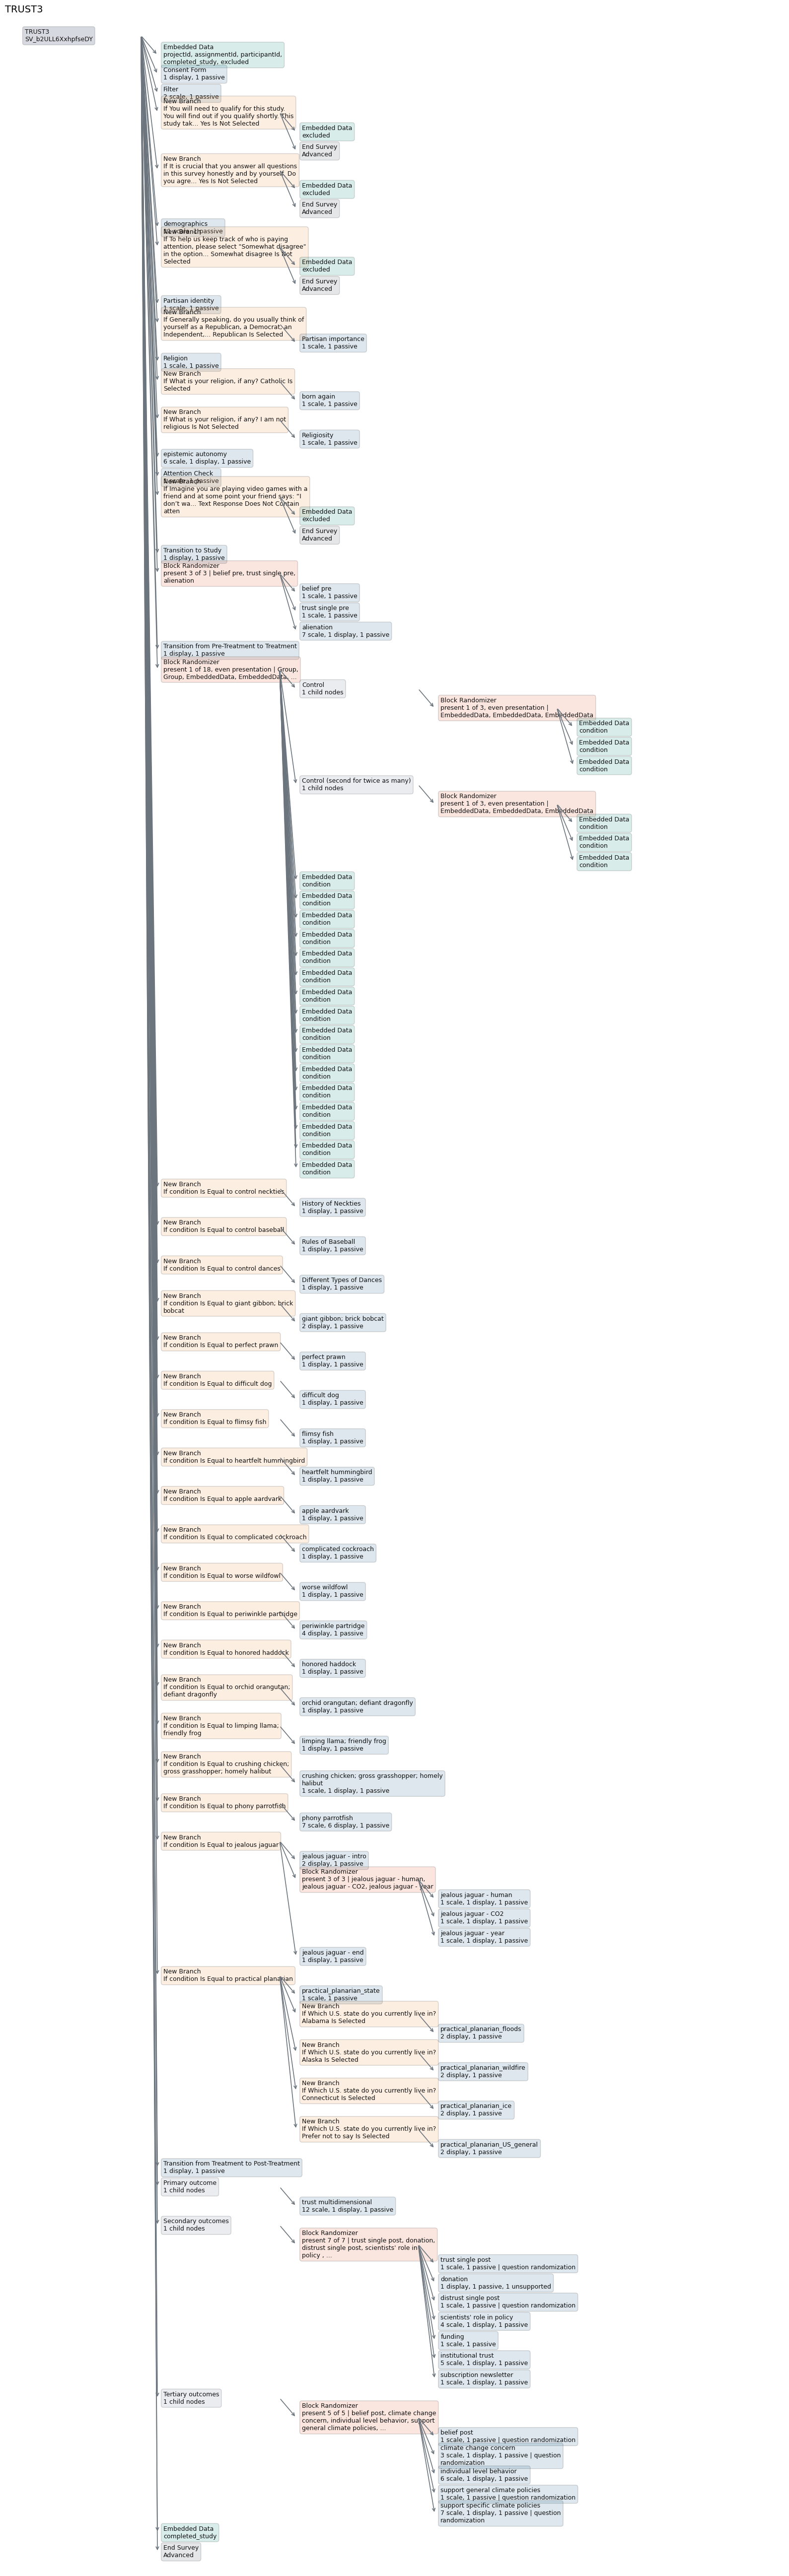

In [9]:
fig, ax = visualize_survey_flow(survey, figsize=(16, 52))
fig.canvas.draw()


## Random Adult GSS Sample

The packaged `gss_personas.csv` pool is used as the persona frame. The notebook samples the requested pilot and full-run participant counts randomly from adult GSS personas. When the requested count is larger than the available adult GSS pool, rows are sampled with replacement and assigned unique simulation ids while preserving the source persona id.


In [10]:
gss_personas_df = load_adult_gss_personas()
full_participant_count = sum(full_condition_counts.values())

pilot_personas_df = sample_gss_personas(
    gss_personas_df,
    len(condition_options),
    seed=SEED,
    sample_name="pilot",
)
full_personas_df = sample_gss_personas(
    gss_personas_df,
    full_participant_count,
    seed=SEED + 1,
    sample_name="full",
)

pilot_participant_ids = pilot_personas_df["id"].tolist()
full_participant_ids = full_personas_df["id"].tolist()

print("Adult GSS persona pool:", len(gss_personas_df))
print("Pilot participants:", len(pilot_participant_ids), "replace:", len(pilot_participant_ids) > len(gss_personas_df))
print("Full participants:", len(full_participant_ids), "replace:", len(full_participant_ids) > len(gss_personas_df))
print("Full source personas reused:", int(full_personas_df["source_persona_id"].duplicated().sum()))


Adult GSS persona pool: 9000
Pilot participants: 18 replace: False
Full participants: 9000 replace: False
Full source personas reused: 0


In [12]:
sample_summary = pd.DataFrame(
    [
        {
            "sample": "pilot",
            "rows": len(pilot_personas_df),
            "unique_source_personas": pilot_personas_df["source_persona_id"].nunique(),
            "sampled_with_replacement": len(pilot_personas_df) > len(gss_personas_df),
        },
        {
            "sample": "full",
            "rows": len(full_personas_df),
            "unique_source_personas": full_personas_df["source_persona_id"].nunique(),
            "sampled_with_replacement": len(full_personas_df) > len(gss_personas_df),
        },
    ]
)

sample_summary


,sample,rows,unique_source_personas,sampled_with_replacement
0,pilot,18,18,False
1,full,9000,500,True


In [13]:
pilot_preview_lab = Lab(
    client=None,
    df=pilot_personas_df.copy(),
    user_model=USER_MODEL,
    user_temperature=USER_TEMPERATURE,
    user_max_tokens=USER_MAX_TOKENS,
    seed=SEED,
)
full_preview_lab = Lab(
    client=None,
    df=full_personas_df.copy(),
    user_model=USER_MODEL,
    user_temperature=USER_TEMPERATURE,
    user_max_tokens=USER_MAX_TOKENS,
    seed=SEED,
)

pilot_even_plan = pilot_preview_lab.describe_even_presentation_plan(
    sampled_users=pilot_participant_ids,
    user_system_texts=participant_prompt,
    survey=survey,
    even_presentation_counts={TOP_LEVEL_RANDOMIZER_ID: pilot_condition_counts},
)

full_even_plan = full_preview_lab.describe_even_presentation_plan(
    sampled_users=full_participant_ids,
    user_system_texts=participant_prompt,
    survey=survey,
    even_presentation_counts={TOP_LEVEL_RANDOMIZER_ID: full_condition_counts},
)

pilot_even_plan, full_even_plan[:1]


([{'flow_id': 'FL_18',
   'path': 'Survey Flow > FL_18',
   'subset': 1,
   'option_count': 18,
   'options': ['Control',
    'Control (second for twice as many)',
    'FL_208',
    'FL_209',
    'FL_210',
    'FL_212',
    'FL_213',
    'FL_214',
    'FL_215',
    'FL_216',
    'FL_217',
    'FL_218',
    'FL_219',
    'FL_220',
    'FL_221',
    'FL_222',
    'FL_223',
    'FL_224'],
   'planned_counts': {'Control': 1,
    'Control (second for twice as many)': 1,
    'FL_208': 1,
    'FL_209': 1,
    'FL_210': 1,
    'FL_212': 1,
    'FL_213': 1,
    'FL_214': 1,
    'FL_215': 1,
    'FL_216': 1,
    'FL_217': 1,
    'FL_218': 1,
    'FL_219': 1,
    'FL_220': 1,
    'FL_221': 1,
    'FL_222': 1,
    'FL_223': 1,
    'FL_224': 1},
   'requested_counts': {'Control': 1,
    'Control (second for twice as many)': 1,
    'FL_208': 1,
    'FL_209': 1,
    'FL_210': 1,
    'FL_212': 1,
    'FL_213': 1,
    'FL_214': 1,
    'FL_215': 1,
    'FL_216': 1,
    'FL_217': 1,
    'FL_218': 1,
    

## Tiny Pilot Run

This pilot assigns `1` participant to every active condition, including each control condition. The total pilot size is derived automatically from the number of active conditions in the current survey setup. The cell skips cleanly when API credentials are not present.


In [14]:
import time 
start = time.time()
PILOT_RAW_PATH = RESULTS_DIR / f"trust_new_pilot_raw_results_dynamic_conditions_seed{SEED}.json"
PILOT_FORMATTED_PATH = RESULTS_DIR / f"trust_new_pilot_formatted_results_dynamic_conditions_seed{SEED}.csv"

if not (os.environ.get("OPENAI_API_KEY") or os.environ.get("OPENROUTER_API_KEY")):
    print("Skipping live pilot run. Set OPENAI_API_KEY or OPENROUTER_API_KEY to execute this cell.")
else:
    pilot_lab, pilot_plan, pilot_raw_results, pilot_formatted_results = run_batch(
        personas_df=pilot_personas_df,
        participant_ids=pilot_participant_ids,
        participant_prompt=participant_prompt,
        condition_counts=pilot_condition_counts,
        intervention_overrides=text_only_intervention_overrides,
    )
    pilot_lab.save_results(pilot_raw_results, PILOT_RAW_PATH)
    pilot_formatted_results.to_csv(PILOT_FORMATTED_PATH, index=False)
    print("Saved pilot raw results to", PILOT_RAW_PATH)
    print("Saved pilot formatted results to", PILOT_FORMATTED_PATH)
    pilot_formatted_results[["id", "survey_embedded_condition"]].head()
end = time.time()
print("Pilot run time (seconds):", round(end - start, 2))


Calculating simulation errors...
Saved to /Users/yara/GitHub/human-ai-eval/studies/trust/results/trust_new_pilot_raw_results_dynamic_conditions_seed42.json
Saved pilot raw results to /Users/yara/GitHub/human-ai-eval/studies/trust/results/trust_new_pilot_raw_results_dynamic_conditions_seed42.json
Saved pilot formatted results to /Users/yara/GitHub/human-ai-eval/studies/trust/results/trust_new_pilot_formatted_results_dynamic_conditions_seed42.csv
Pilot run time (seconds): 154.84


## Full Derived-Allocation Run

This cell is the full synthetic generation entry point. It uses the random GSS sample derived above, sends 500 participants to each active treatment branch, and splits the 1,000 control participants across the active control variants.


In [ ]:
FULL_RAW_PATH = RESULTS_DIR / f"trust_new_raw_results_n{sum(full_condition_counts.values())}_seed{SEED}.json"
FULL_FORMATTED_PATH = RESULTS_DIR / f"trust_new_formatted_results_n{sum(full_condition_counts.values())}_seed{SEED}.csv"

RUN_FULL_GENERATION = False

if not RUN_FULL_GENERATION:
    print(f"Set RUN_FULL_GENERATION = True to launch the full {sum(full_condition_counts.values()):,}-participant run.")
elif not (os.environ.get("OPENAI_API_KEY") or os.environ.get("OPENROUTER_API_KEY")):
    print("Skipping full run. Set OPENAI_API_KEY or OPENROUTER_API_KEY to execute this cell.")
else:
    full_lab, full_plan, full_raw_results, full_formatted_results = run_batch(
        personas_df=full_personas_df,
        participant_ids=full_participant_ids,
        participant_prompt=participant_prompt,
        condition_counts=full_condition_counts,
        intervention_overrides=text_only_intervention_overrides,
    )
    full_lab.save_results(full_raw_results, FULL_RAW_PATH)
    full_formatted_results.to_csv(FULL_FORMATTED_PATH, index=False)
    print("Saved full raw results to", FULL_RAW_PATH)
    print("Saved full formatted results to", FULL_FORMATTED_PATH)
    print("Successful rows:", len(full_formatted_results))
